# Human Activity Recognition with Wifi

In [48]:
import numpy as np
import numpy.random as rnd
import torch
import matplotlib.pyplot as plt

from models.DopplerDataset import * 
from models.SHARP import *
from utilities.training import *
from utilities.plotting import *
from utilities.dataset_separation import *

from time import time 
from torchvision.transforms import Compose, ToTensor, RandomHorizontalFlip, RandomVerticalFlip
from torch.utils.data import DataLoader
from os import listdir, makedirs, path
from glob import glob
from tqdm import tqdm

%load_ext autoreload
%autoreload 2


###############  GLOBAL VARIABLES  #################
DEBUG_MODE                 = True

PERFORM_DATASET_SEPARATION = True
DATASET_PATH               = "doppler_traces/S2*"
TEST_DATASET_FRACTION      = 1
DOPPLER_TRACE_SIZE         = 340
LABELS                 = ['W', 'E', 'R', 'J', 'L']
ACTIVITIES             = ['Walking', 'Empty', 'Running', 'Jumping', 'Sitting']

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Separating training dataset and test dataset

In [49]:
'''
    We split each Doppler trace in DATASET_PATH into several Doppler sub-traces of size DOPPLER_TRACE_SIZE,
    then we randomly split each collection of sub-traces into a train/test dataset folder.
'''
create_train_dataset(DATASET_PATH, DOPPLER_TRACE_SIZE, LABELS)
create_test_dataset(DATASET_PATH, DOPPLER_TRACE_SIZE, LABELS)

Datasets are already splitted!
Dataset is already splitted!



## Loading Dataset

Loading dataset doppler_traces_train in memory...


2816it [00:01, 1512.97it/s]


Dataset is loaded!

---------- DATASET INFO ----------

Dataset directory:
doppler_traces_train
Labels dictionary:
{'W': 0, 'E': 1, 'R': 2, 'J': 3, 'L': 4}

----------------------------------

Loading dataset doppler_traces_test in memory...


2816it [00:01, 1517.83it/s]


Dataset is loaded!

---------- DATASET INFO ----------

Dataset directory:
doppler_traces_test
Labels dictionary:
{'W': 0, 'E': 1, 'R': 2, 'J': 3, 'L': 4}

----------------------------------



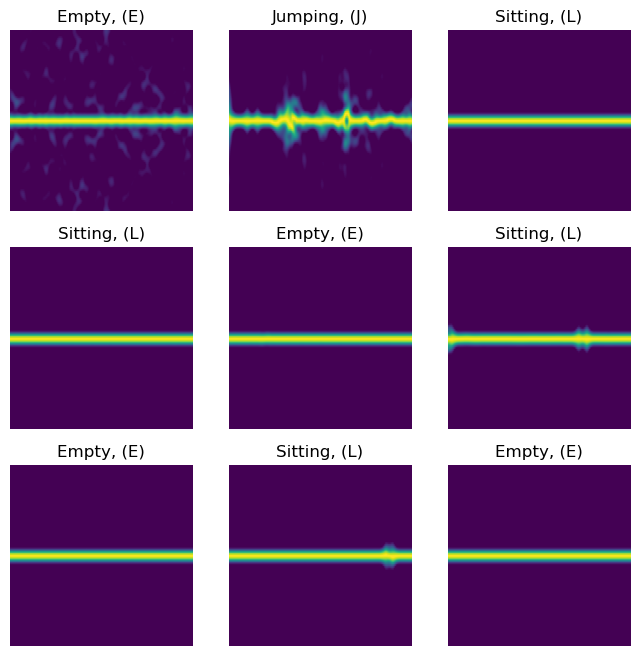

In [51]:
labels_map = {label:idx for idx, label in enumerate(LABELS)}

batch_size = 128
train_dataset  = DopplerDataset("doppler_traces_train", labels_map)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
train_dataset.getInfo()

test_dataset  = DopplerDataset("doppler_traces_test", labels_map)
test_dataloader = DataLoader(test_dataset, batch_size=4, shuffle=False)
test_dataset.getInfo()

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols*rows + 1):
    sample_idx = torch.randint(len(train_dataset), size=(1,)).item()
    img, label_idx = train_dataset[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(f"{ACTIVITIES[label_idx]}, ({LABELS[label_idx]})")
    plt.axis("off")
    plt.imshow(img[0,:,:], aspect='auto')
plt.show()

## Training of SHARP architecure

In [57]:
sharp_model = SHARP(n_features=len(ACTIVITIES))

learning_rate = 1e-4
device    = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
loss_fn   = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=sharp_model.parameters(), lr=learning_rate)

if DEBUG_MODE:
    #### CHECKING DATA TYPES 
    x, y = next(iter(train_dataloader))
    print(x.dtype)
    print(next(sharp_model.parameters()).dtype)
    ### DEVICE
    print(f"Device: {device}")

torch.float32
torch.float32
Device: mps


In [58]:
epochs = 20
train_loss, test_loss, _ = train_model(sharp_model, train_dataloader, test_dataloader, epochs, loss_fn, optimizer, device, verbosity=True)

Starting model training...
Completed epochs: 0/20 ------ Time (total): 0.00 ------ Time (relative): 0.00

Loss: 1.53524e+00 --- Samples:   128/ 2816
Loss: 1.58885e+00 --- Samples:  1408/ 2816
Loss: 1.55500e+00 --- Samples:  2688/ 2816
Test Error: 
 Accuracy: 29.4%, Avg loss: 1.479456 

Completed epochs: 1/20 ------ Time (total): 3.13 ------ Time (relative): 3.13

Loss: 1.52962e+00 --- Samples:   128/ 2816
Loss: 1.46046e+00 --- Samples:  1408/ 2816
Loss: 1.45292e+00 --- Samples:  2688/ 2816
Test Error: 
 Accuracy: 32.8%, Avg loss: 1.417316 

Completed epochs: 2/20 ------ Time (total): 5.98 ------ Time (relative): 2.85

Loss: 1.47200e+00 --- Samples:   128/ 2816
Loss: 1.45201e+00 --- Samples:  1408/ 2816
Loss: 1.36021e+00 --- Samples:  2688/ 2816
Test Error: 
 Accuracy: 42.3%, Avg loss: 1.397321 

Completed epochs: 3/20 ------ Time (total): 8.91 ------ Time (relative): 2.93

Loss: 1.36235e+00 --- Samples:   128/ 2816
Loss: 1.38956e+00 --- Samples:  1408/ 2816
Loss: 1.29651e+00 --- Sample

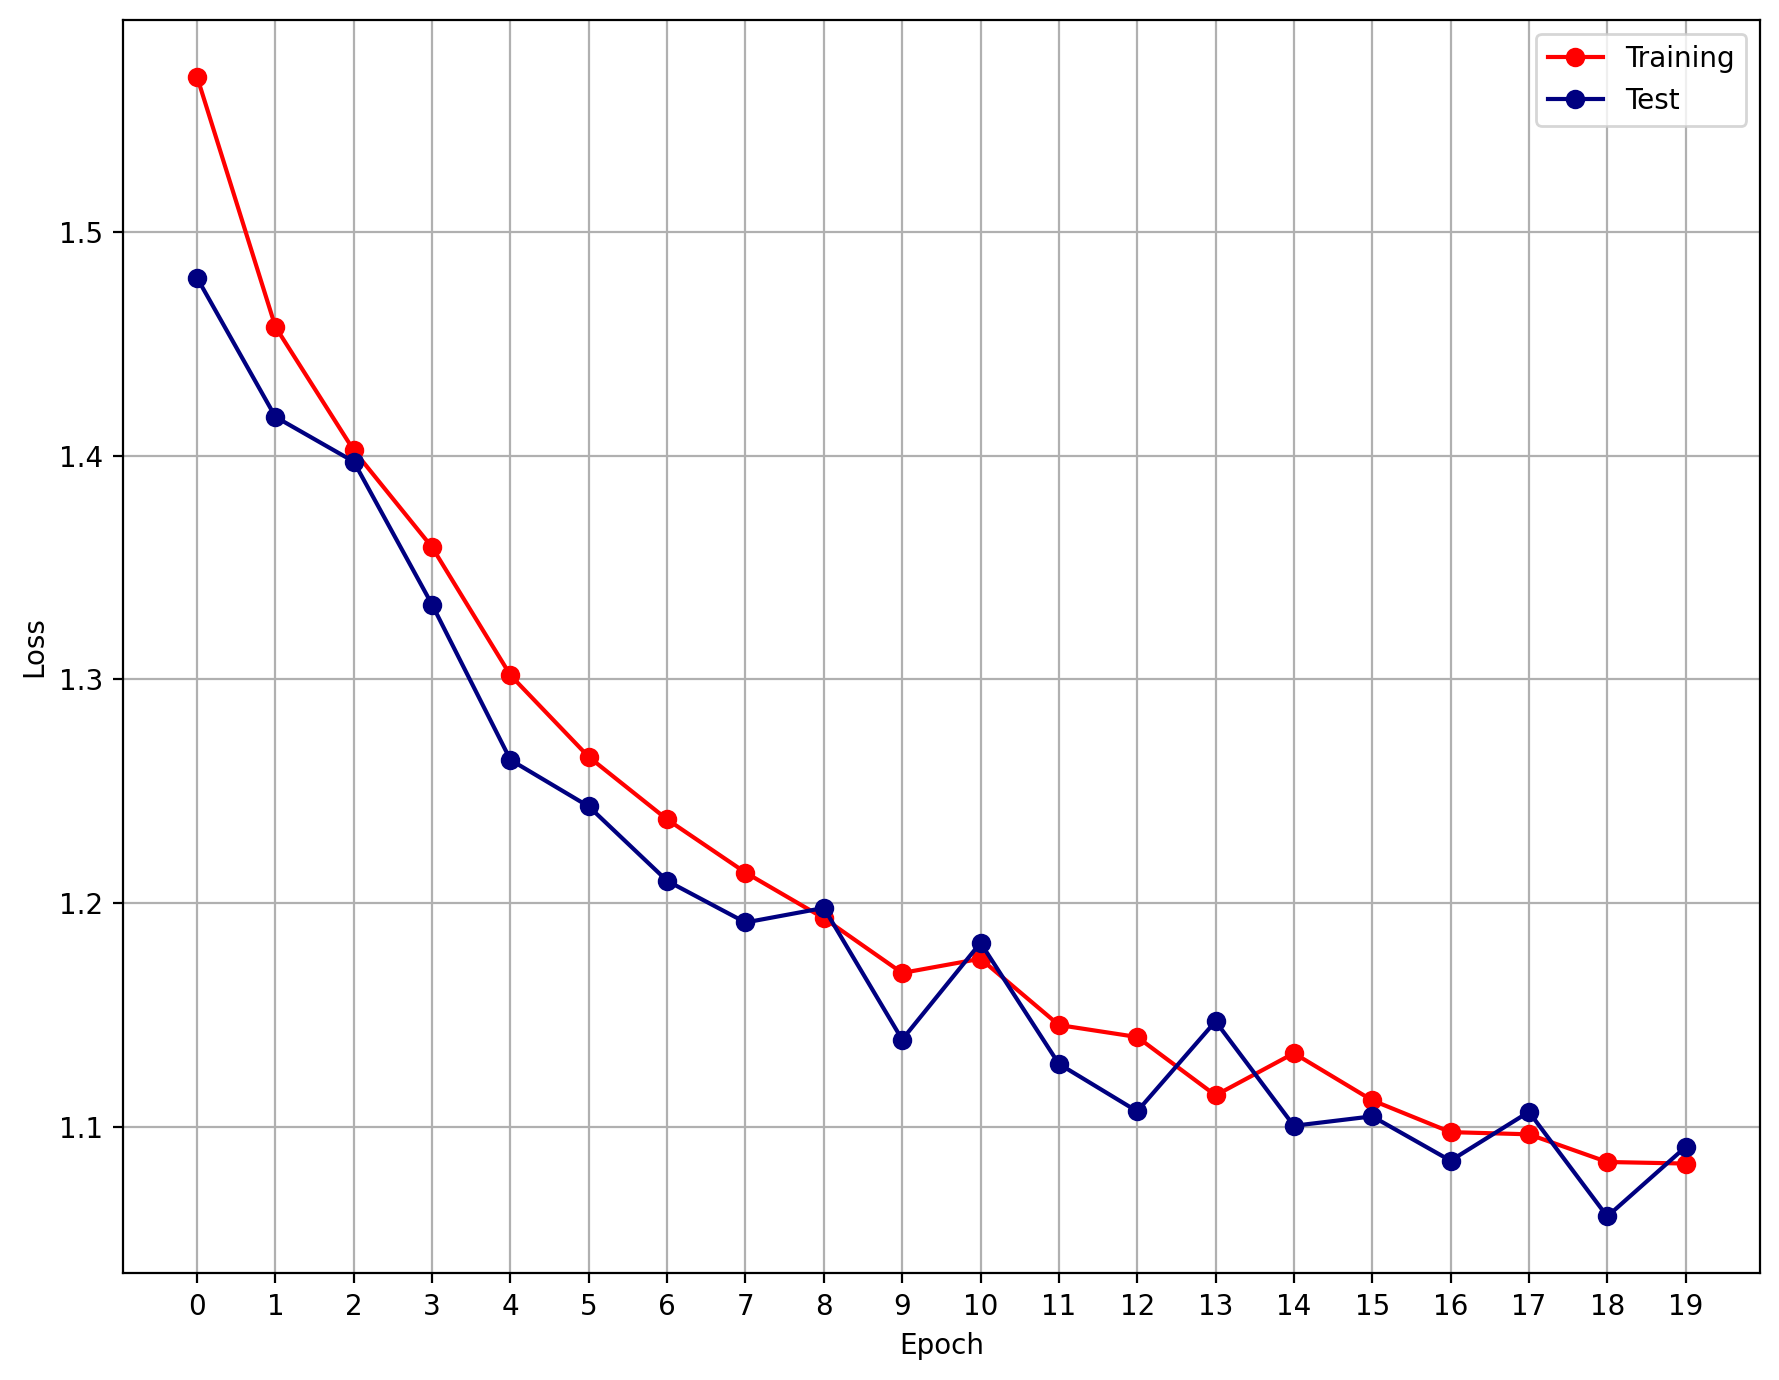

In [59]:
plot_loss(train_loss, test_loss)